<div align="center">

# Business Problem

A leading telecom company wants to better understand customer behavior to improve its marketing strategy. The objective is to analyze customer demographics, service subscriptions, and usage patterns to discover meaningful customer segments and identify relationships between telecom services.

## Business Objectives

- Identify relationships (affinities) between telecom services.
- Reduce data dimensionality using a suitable data reduction technique.
- Apply clustering to discover behavioural customer segments.
- Profile each customer segment using demographic, service, and usage characteristics.
- Recommend business strategies for each segment to improve customer retention, cross-selling, and revenue growth.

## Dataset

The dataset contains customer information including:

**Demographics:** Age, Income, Gender, Education, Employment, Region, Marital Status

**Customer Profile:** Tenure, Customer Category

**Subscribed Services:** Wireless, Internet, Voice Mail, Call Waiting, Toll Free, Equipment Rental, etc.

**Monthly Usage:** Long Distance, Wireless, Equipment Rental, Calling Card, Toll Free usage

</div>

### Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pickle
import warnings
warnings.filterwarnings('ignore')

### Loading the Dataset

In [2]:
data = pd.read_csv('telco_csv.csv')
data.head()

,region,tenure,age,marital,address,income,ed,employ,retire,gender,...,callwait,forward,confer,longmon,tollmon,equipmon,cardmon,wiremon,ebill,custcat
0,2,13,44,1,9,64,4,5,0,0,...,0,1,0,3.70,0.00,0.0,7.50,0.0,0,1
1,3,11,33,1,7,136,5,5,0,0,...,1,1,1,4.40,20.75,0.0,15.25,35.7,0,4
2,3,68,52,1,24,116,1,29,0,1,...,1,0,1,18.15,18.00,0.0,30.25,0.0,0,3
3,2,33,33,0,12,33,2,0,0,1,...,0,0,0,9.45,0.00,0.0,0.00,0.0,0,1
4,2,23,30,1,9,30,1,2,0,0,...,0,1,1,6.30,0.00,0.0,0.00,0.0,0,3


### Data Exploration

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 30 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   region    1000 non-null   int64  
 1   tenure    1000 non-null   int64  
 2   age       1000 non-null   int64  
 3   marital   1000 non-null   int64  
 4   address   1000 non-null   int64  
 5   income    1000 non-null   int64  
 6   ed        1000 non-null   int64  
 7   employ    1000 non-null   int64  
 8   retire    1000 non-null   int64  
 9   gender    1000 non-null   int64  
 10  reside    1000 non-null   int64  
 11  tollfree  1000 non-null   int64  
 12  equip     1000 non-null   int64  
 13  callcard  1000 non-null   int64  
 14  wireless  1000 non-null   int64  
 15  multline  1000 non-null   int64  
 16  voice     1000 non-null   int64  
 17  pager     1000 non-null   int64  
 18  internet  1000 non-null   int64  
 19  callid    1000 non-null   int64  
 20  callwait  1000 non-null   int64

In [4]:
# to check the statistical distribution(skewness) of data and get idea of presence of outliers

data.describe(include = 'all', percentiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.9999]).T

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,99.99%,max
region,1000.0,2.0220,0.816200,1.0,1.00,1.0000,1.000,1.0,2.000,3.0000,3.000,3.0000,3.0000,3.000000,3.00
tenure,1000.0,35.5260,21.359812,1.0,1.00,4.0000,7.000,17.0,34.000,54.0000,66.000,70.0000,72.0000,72.000000,72.00
age,1000.0,41.6840,12.558816,18.0,20.00,23.0000,26.000,32.0,40.000,51.0000,59.000,64.0000,70.0100,76.900100,77.00
marital,1000.0,0.4950,0.500225,0.0,0.00,0.0000,0.000,0.0,0.000,1.0000,1.000,1.0000,1.0000,1.000000,1.00
address,1000.0,11.5510,10.086681,0.0,0.00,0.0000,1.000,3.0,9.000,18.0000,26.100,31.0000,43.0000,54.400600,55.00
income,1000.0,77.5350,107.044165,9.0,10.99,18.0000,21.000,29.0,47.000,83.0000,155.400,232.2500,460.4800,1614.353700,1668.00
ed,1000.0,2.6710,1.222397,1.0,1.00,1.0000,1.000,2.0,3.000,4.0000,4.000,5.0000,5.0000,5.000000,5.00
employ,1000.0,10.9870,10.082087,0.0,0.00,0.0000,0.000,3.0,8.000,17.0000,25.000,31.0000,40.0100,46.800200,47.00
retire,1000.0,0.0470,0.211745,0.0,0.00,0.0000,0.000,0.0,0.000,0.0000,0.000,0.0000,1.0000,1.000000,1.00
gender,1000.0,0.5170,0.499961,0.0,0.00,0.0000,0.000,0.0,1.000,1.0000,1.000,1.0000,1.0000,1.000000,1.00


In [5]:
# chekc the presence of outliers

data[data['income']>460].shape[0]

10

In [6]:
# number of unique values for each feature

data.nunique()

region        3
tenure       72
age          60
marital       2
address      50
income      218
ed            5
employ       46
retire        2
gender        2
reside        8
tollfree      2
equip         2
callcard      2
wireless      2
multline      2
voice         2
pager         2
internet      2
callid        2
callwait      2
forward       2
confer        2
longmon     425
tollmon     162
equipmon    310
cardmon     176
wiremon     263
ebill         2
custcat       4
dtype: int64

### Data Quality Checks

In [7]:
# if columns names are not proper
data.columns = [col.strip().lower().replace(' ','_') for col in data.columns]   

In [8]:
# chcck null values presence
data.isna().sum()

region      0
tenure      0
age         0
marital     0
address     0
income      0
ed          0
employ      0
retire      0
gender      0
reside      0
tollfree    0
equip       0
callcard    0
wireless    0
multline    0
voice       0
pager       0
internet    0
callid      0
callwait    0
forward     0
confer      0
longmon     0
tollmon     0
equipmon    0
cardmon     0
wiremon     0
ebill       0
custcat     0
dtype: int64

In [9]:
# check presence of duplicates
data.duplicated().sum()
# if duplicates are present in data we will remove duplicates using .drop_duplicates(keep = 'first' or 'last' based on dates) function 

0

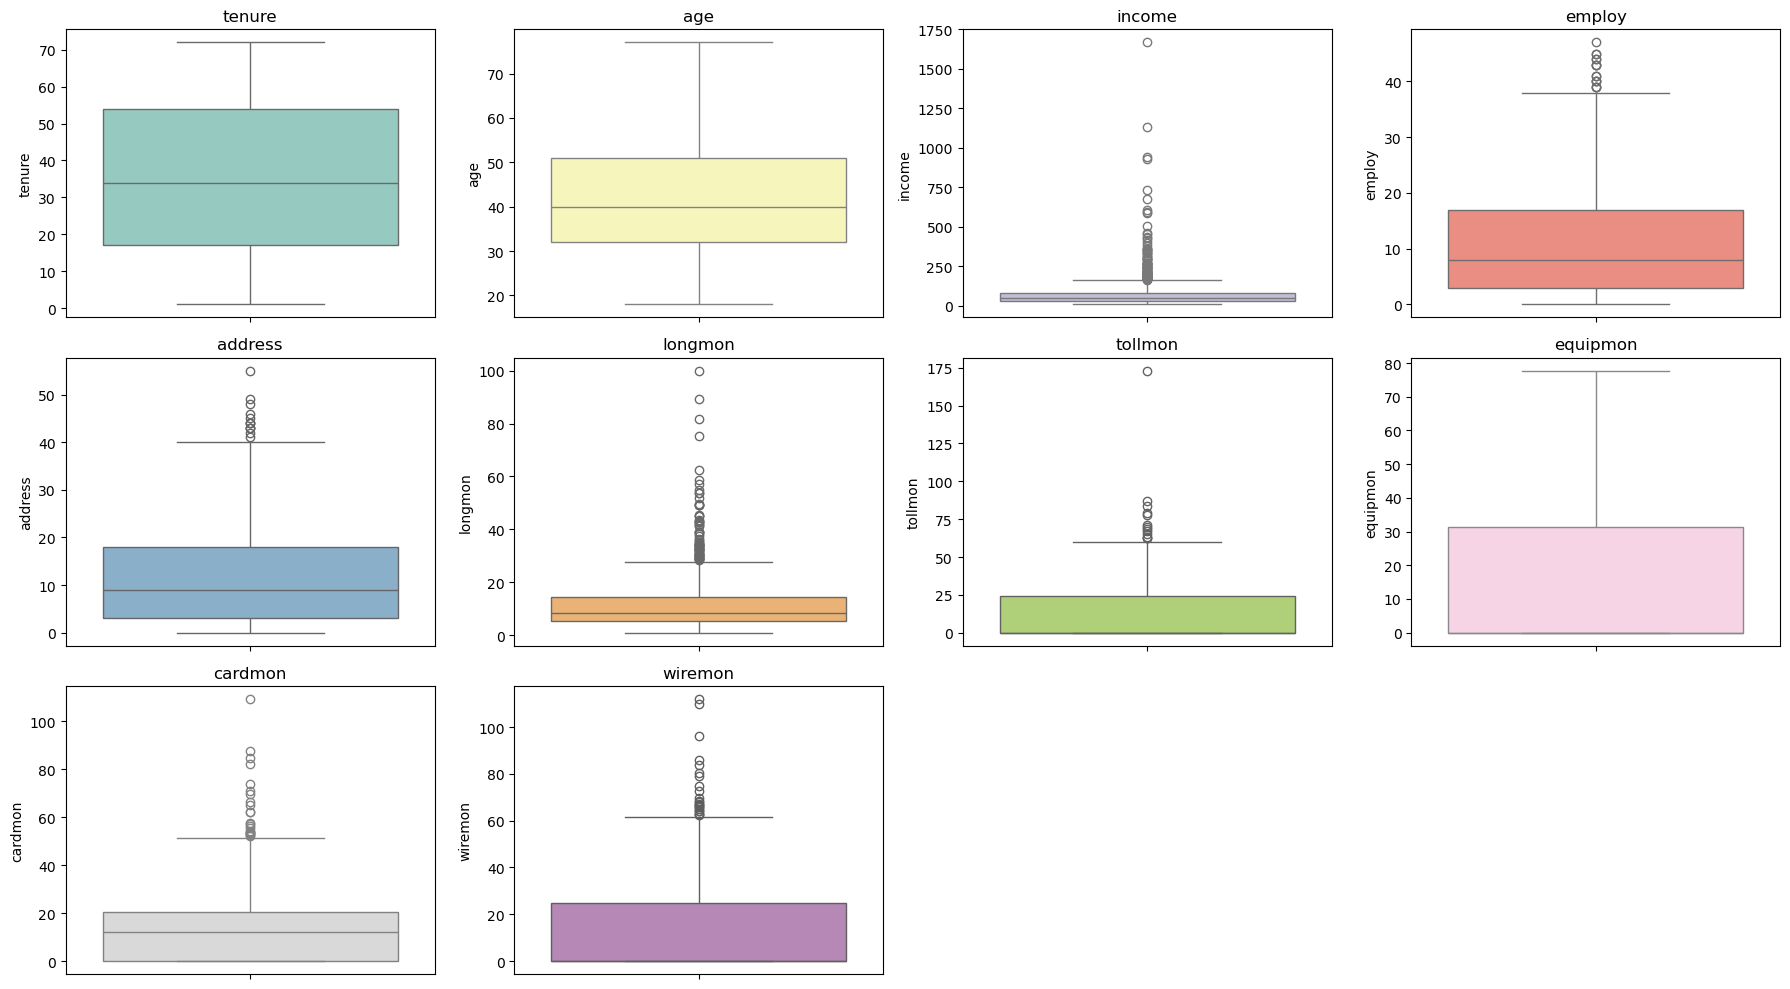

In [10]:
# check presence of outliers 

outlier_check = ['tenure', 'age', 'income', 'employ', 'address', 'longmon', 'tollmon', 'equipmon','cardmon', 'wiremon']
colors = sns.color_palette("Set3", len(outlier_check))

fig, axes = plt.subplots(3, 4, figsize=(18, 10))
for ax, col, clr in zip(axes.flatten(), outlier_check, colors):
    sns.boxplot(y=data[col], ax=ax, color=clr)
    ax.set_title(col)

for ax in axes.flatten()[len(outlier_check):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [11]:
# Identify column types

num_cols = []
obj_cols = []

for col in data.columns:
    if data[col].dtype in ['int52', 'int64', 'float64']:
        num_cols.append(col)
    else:
        obj_cols.append(col)

print(f'Numeric columns   : {len(num_cols)}')
print(f'Object columns    : {obj_cols}')

Numeric columns   : 30
Object columns    : []


#### Missings Handling

In [12]:
num_imputer = SimpleImputer(strategy='median').fit(data[num_cols])

data_imp = data.copy()

data_imp[num_cols] = num_imputer.transform(data[num_cols])

In [13]:
# check presence of null values 
data_imp.isna().sum().sum()

0

#### Outlier Handling

In [14]:
clip_cutoffs = {}

for col in num_cols:
    lc = data_imp[col].quantile(0.01) 
    uc = data_imp[col].quantile(0.99)
    clip_cutoffs[col] = (lc, uc)

data_clipped = data_imp.copy()

for col, (lc, uc) in clip_cutoffs.items():
    data_clipped[col] = data_imp[col].clip(lower=lc, upper=uc)

In [15]:
data_clipped.describe(percentiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.9999]).T

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,99.99%,max
region,1000.0,2.022000,0.816200,1.00,1.0000,1.0000,1.000,1.0,2.000,3.0000,3.000,3.0000,3.000000,3.0000,3.0000
tenure,1000.0,35.526000,21.359812,1.00,1.0000,4.0000,7.000,17.0,34.000,54.0000,66.000,70.0000,72.000000,72.0000,72.0000
age,1000.0,41.645100,12.436692,20.00,20.0000,23.0000,26.000,32.0,40.000,51.0000,59.000,64.0000,70.000100,70.0100,70.0100
marital,1000.0,0.495000,0.500225,0.00,0.0000,0.0000,0.000,0.0,0.000,1.0000,1.000,1.0000,1.000000,1.0000,1.0000
address,1000.0,11.520000,9.978335,0.00,0.0000,0.0000,1.000,3.0,9.000,18.0000,26.100,31.0000,43.000000,43.0000,43.0000
income,1000.0,73.785700,77.561159,10.99,10.9999,18.0000,21.000,29.0,47.000,83.0000,155.400,232.2500,460.004800,460.4800,460.4800
ed,1000.0,2.671000,1.222397,1.00,1.0000,1.0000,1.000,2.0,3.000,4.0000,4.000,5.0000,5.000000,5.0000,5.0000
employ,1000.0,10.951100,9.970046,0.00,0.0000,0.0000,0.000,3.0,8.000,17.0000,25.000,31.0000,40.000100,40.0100,40.0100
retire,1000.0,0.047000,0.211745,0.00,0.0000,0.0000,0.000,0.0,0.000,0.0000,0.000,0.0000,1.000000,1.0000,1.0000
gender,1000.0,0.517000,0.499961,0.00,0.0000,0.0000,0.000,0.0,1.000,1.0000,1.000,1.0000,1.000000,1.0000,1.0000


#### Encoding Categorical Variables

In [16]:
from sklearn.preprocessing import OneHotEncoder

In [17]:
data_encd = data_clipped.copy()
ohe_cols = ['region','custcat']   # add nominal features here
data_encd[ohe_cols] = data_encd[ohe_cols].astype(int) 

#  OneHotEncoding for region bcus they are present in numerical form but in actual they have nominal categorical properties so we apply ohe encoding on it 
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).fit(data_encd[ohe_cols])
ohe_col_names = list(ohe.get_feature_names_out(ohe_cols))

ohe_data = pd.DataFrame(ohe.transform(data_encd[ohe_cols]),columns=ohe_col_names, index=data_encd.index)

# Concat OHE cols, drop originals
data_encd = pd.concat([data_encd.drop(columns=ohe_cols), ohe_data], axis=1)
data_encd.head()

,tenure,age,marital,address,income,ed,employ,retire,gender,reside,...,cardmon,wiremon,ebill,region_1,region_2,region_3,custcat_1,custcat_2,custcat_3,custcat_4
0,13.0,44.0,1.0,9.0,64.0,4.0,5.0,0.0,0.0,2.0,...,7.50,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
1,11.0,33.0,1.0,7.0,136.0,5.0,5.0,0.0,0.0,6.0,...,15.25,35.7,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,68.0,52.0,1.0,24.0,116.0,1.0,29.0,0.0,1.0,2.0,...,30.25,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,33.0,33.0,0.0,12.0,33.0,2.0,0.0,0.0,1.0,1.0,...,0.00,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,23.0,30.0,1.0,9.0,30.0,1.0,2.0,0.0,0.0,4.0,...,0.00,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


#### Featire engineering

In [18]:
service_cols = ['tollfree', 'equip', 'callcard', 'wireless', 'multline', 'voice', 'pager', 'internet','callid', 'callwait', 'forward', 'confer', 'ebill'] # 15 binary service columns
usage_cols = ['longmon', 'tollmon', 'equipmon', 'cardmon', 'wiremon'] # 5 usage columns, We can also give them separately in cluster features on the place of total_mon_usages
cat_cols  = ['custcat_1','custcat_2','custcat_3','custcat_4','region_1','region_2','region_3', 'marital','retire','gender']   # kmeans euclidean distance can be harmed by these so not use them but will use in profilling 

# Service adoption score (binary)
data_encd['total_services'] = data_encd[service_cols].sum(axis=1)

# Usage intensity  
data_encd['total_mon_usage'] = data_encd[usage_cols].sum(axis=1)
data_encd['avg_mon_usage'] = data_encd[usage_cols].mean(axis=1)

# Subcategories of services 
data_encd['value_added_services'] = data_encd[['voice', 'pager', 'internet', 'callid','callwait', 'forward', 'confer', 'ebill']].sum(axis=1)
data_encd['connectivity_services'] = data_encd[['tollfree', 'equip', 'callcard','wireless', 'multline']].sum(axis=1)

# Usage-to-service ratio  
data_encd['usage_per_service'] = data_encd['total_mon_usage'] / (data_encd['total_services'] + 1)

# Loyalty / tenure signal
data_encd['loyalty_score'] = data_encd['tenure'] * data_encd['income'] / 1000  # customer have high tenure + high income  are loyal 

cluster_features = ['longmon','tollmon','wiremon','value_added_services','connectivity_services','usage_per_service','loyalty_score']    

#cluster_features = ['tenure', 'age', 'address', 'income', 'ed', 'employ', 'reside', 'longmon', 'tollmon', 'wiremon','value_added_services',
                 #   'connectivity_services']   ## Note: with all of these model performance is low because data is overlapping so take few feature based on problem 
 
#loyalti_score, avg_mon_socre,tot_mon_sccore, total_services can cause multicolinearity so not added them 
# marital, retire, gender are binary demographics KMeans uses Euclidean distance which does not handle binary features well. so we use them only
# in profiling (to describe clusters after they are formed), not for forming the clusters.

In [19]:
data_encd.shape

(1000, 42)

In [20]:
data_encd.skew().sort_values()

callcard                -0.763061
gender                  -0.068142
confer                  -0.008012
marital                  0.020031
forward                  0.028045
callwait                 0.060117
callid                   0.076169
multline                 0.100276
tollfree                 0.104297
tenure                   0.111860
ed                       0.193271
connectivity_services    0.215292
age                      0.313856
value_added_services     0.353713
total_services           0.383806
equip                    0.469039
ebill                    0.534884
internet                 0.548244
region_3                 0.657772
region_2                 0.704985
region_1                 0.763061
equipmon                 0.809210
voice                    0.853487
wireless                 0.895118
reside                   0.936455
tollmon                  0.956352
custcat_3                0.975908
employ                   1.001388
total_mon_usage          1.009375
avg_mon_usage 

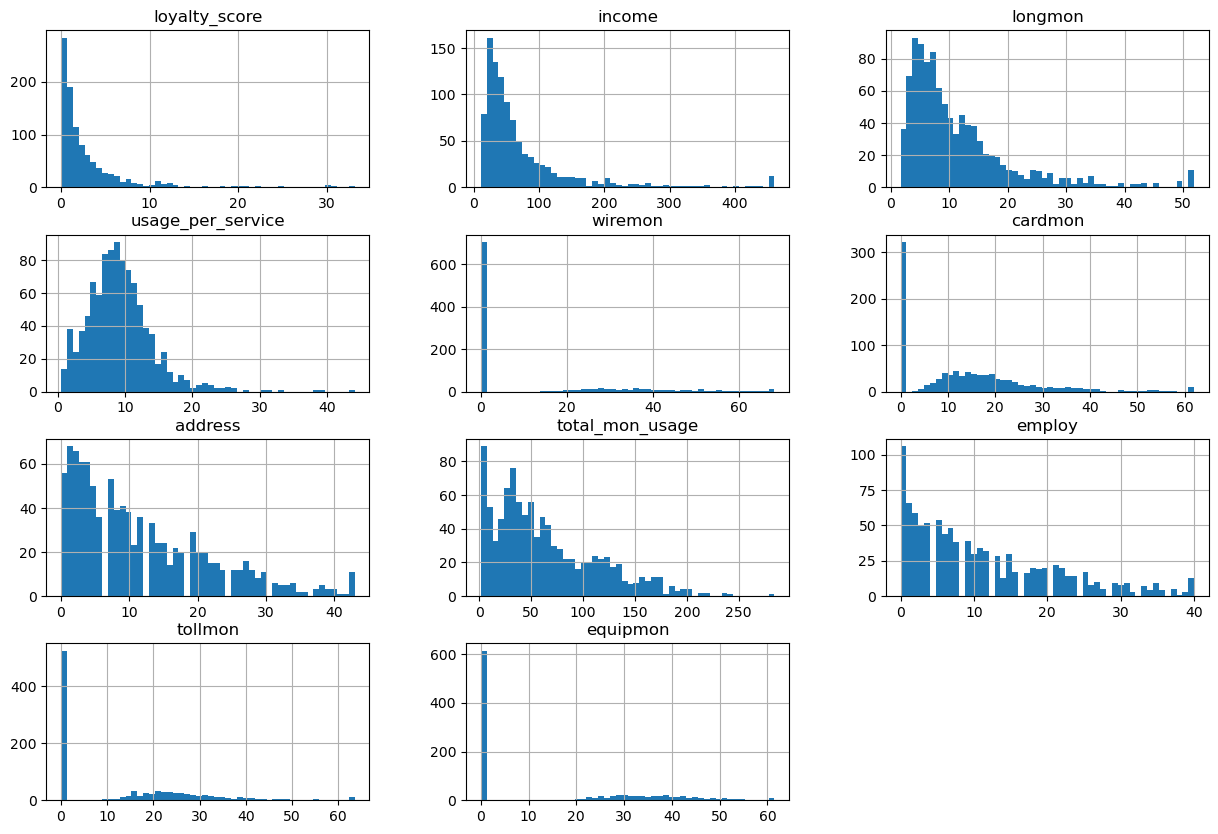

In [21]:
# check skewness  
skew_check = ['loyalty_score','income','longmon','usage_per_service', 'wiremon','cardmon','address','total_mon_usage','employ','tollmon','equipmon'] 

data_encd[skew_check].hist(bins=50, figsize=(15,10))
plt.show()
# don't tretskewness of usage(wiremon, cardmon, tolmon, equipness) variable because large spike at zero tells an important business story, tretment can reduces the contrast between light users and heavy users.

##### Never scale binary features as they are already in normalized form and if we sacle them StandardScaler maps {0, 1} to {-mean/std, (1-mean)/std} — two spiky values
##### if our data has a lot of binary columns then we don't pass them directly to distance based algorithms like knn, kmeans, pca, svm, dbscan, hierarchical clustering, binary dimensions dominate the distance calculation and add pure noise. instead of that we can do groupping, feature engineering and pass onlySelect only the engineered + key continuous feature to algo's 

#### Scaling

In [22]:
data_scaled = data_encd.copy()

cols_to_scale = [col for col in data_encd.columns if data_encd[col].nunique() > 2]
print(f'Total columns to scale : {len(cols_to_scale)}')
print(f'Columns to scale : {cols_to_scale}\n')

ss_telco = StandardScaler().fit(data_encd[cols_to_scale])   # <-- name it properly
data_scaled[cols_to_scale] = ss_telco.transform(data_encd[cols_to_scale])
data_scaled.head()

Total columns to scale : 19
Columns to scale : ['tenure', 'age', 'address', 'income', 'ed', 'employ', 'reside', 'longmon', 'tollmon', 'equipmon', 'cardmon', 'wiremon', 'total_services', 'total_mon_usage', 'avg_mon_usage', 'value_added_services', 'connectivity_services', 'usage_per_service', 'loyalty_score']



,tenure,age,marital,address,income,ed,employ,retire,gender,reside,...,custcat_2,custcat_3,custcat_4,total_services,total_mon_usage,avg_mon_usage,value_added_services,connectivity_services,usage_per_service,loyalty_score
0,-1.055125,0.189446,1.0,-0.252674,-0.126231,1.087753,-0.597197,0.0,0.0,-0.229045,...,0.0,0.0,0.0,-0.977126,-1.061137,-1.061137,-0.922932,-0.905992,-1.121280,-0.486103
1,-1.148806,-0.695476,1.0,-0.453208,0.802534,1.906227,-0.597197,0.0,0.0,2.607427,...,0.0,0.0,1.0,0.936663,0.247491,0.247491,1.114446,0.478259,-0.337355,-0.343963
2,1.521092,0.833025,1.0,1.251336,0.544543,-1.367671,1.811218,0.0,1.0,-0.229045,...,0.0,1.0,0.0,-0.156931,0.051903,0.051903,-0.107981,-0.213867,0.361639,1.024349
3,-0.118319,-0.695476,0.0,0.048128,-0.526115,-0.549196,-1.098950,0.0,1.0,-0.938163,...,0.0,0.0,0.0,-1.523922,-1.096423,-1.096423,-1.330408,-1.598118,0.034722,-0.431088
4,-0.586722,-0.936819,1.0,-0.252674,-0.564814,-1.367671,-0.898249,0.0,0.0,1.189191,...,0.0,1.0,0.0,-0.703727,-1.159939,-1.159939,-0.107981,-1.598118,-1.557730,-0.516500


In [23]:
data_scaled.columns

Index(['tenure', 'age', 'marital', 'address', 'income', 'ed', 'employ',
       'retire', 'gender', 'reside', 'tollfree', 'equip', 'callcard',
       'wireless', 'multline', 'voice', 'pager', 'internet', 'callid',
       'callwait', 'forward', 'confer', 'longmon', 'tollmon', 'equipmon',
       'cardmon', 'wiremon', 'ebill', 'region_1', 'region_2', 'region_3',
       'custcat_1', 'custcat_2', 'custcat_3', 'custcat_4', 'total_services',
       'total_mon_usage', 'avg_mon_usage', 'value_added_services',
       'connectivity_services', 'usage_per_service', 'loyalty_score'],
      dtype='object')

In [24]:
print('columns:',data_scaled[cluster_features].columns,'\n')
print('number of rows and columns:',data_scaled.shape )

columns: Index(['longmon', 'tollmon', 'wiremon', 'value_added_services',
       'connectivity_services', 'usage_per_service', 'loyalty_score'],
      dtype='object') 

number of rows and columns: (1000, 42)


#### Applying feature sekection or reduce features using vif, correlation 

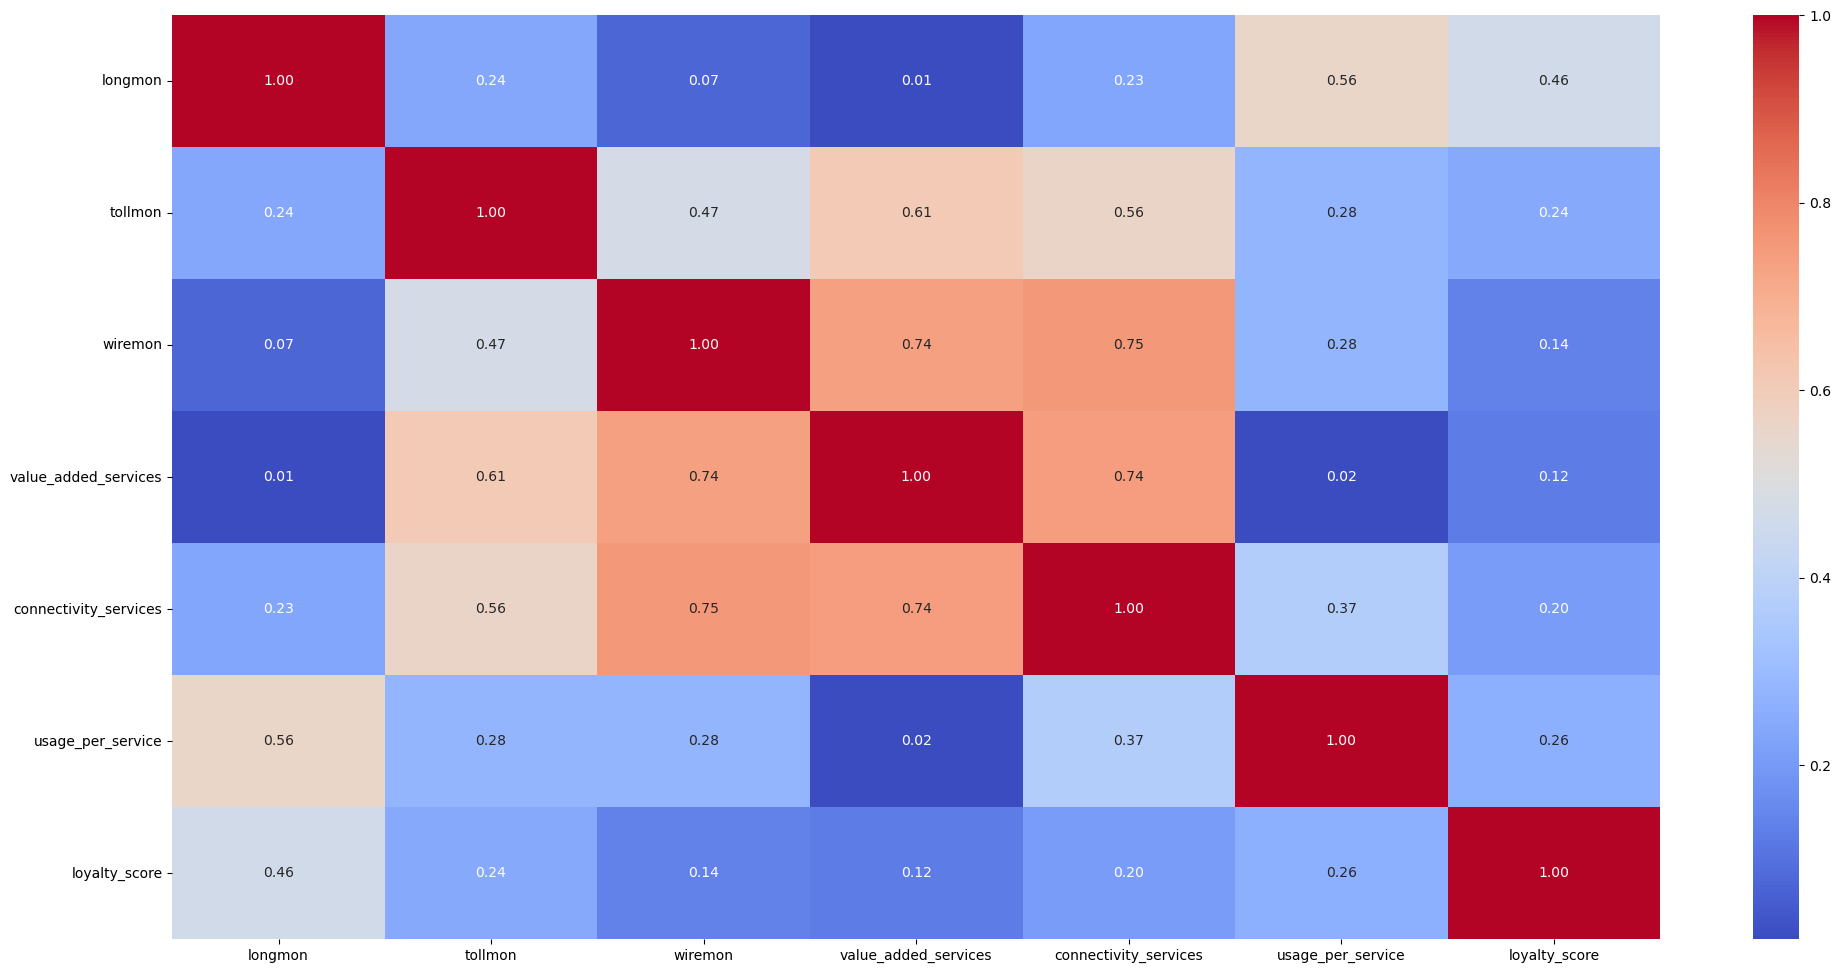

In [25]:
# check correlation between features
plt.figure(figsize=(24,12))
sns.heatmap(data_scaled[cluster_features].corr(numeric_only=True), fmt = '.2f',annot = True, cmap = 'coolwarm')
plt.show()

In [26]:
# create udf to find highly correalted featues  ( check correlation between features )
      
def correlated_detection(df, threshold):
    corr_col = set()
    corr_matrix = df.corr()

    for i in range(len(corr_matrix)):     # to check correlation below the diagonal of matrix
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold:
                columns = corr_matrix.columns[i]   # to select the first feature that is correlated with the other
                corr_col.add(columns)            
    return sorted(corr_col)

corr_cols = correlated_detection(data_scaled[cluster_features], threshold=0.9)
print(f'Correlated columns to drop : {len(corr_cols)}')
print(corr_cols)

Correlated columns to drop : 0
[]


#### multicolinearity handling (only extreme multicolinearity)

In [27]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [28]:
telco_final = data_scaled[cluster_features][data_scaled[cluster_features].columns.difference([ ])]
vif_df = pd.DataFrame()
vif_df['Features'] = telco_final.columns
vif_df['vif_score'] = [variance_inflation_factor(telco_final.values, i) for i in range(telco_final.shape[1])]
vif_df = vif_df.sort_values(by = 'vif_score', ascending = False).reset_index(drop=True)
vif_df

,Features,vif_score
0,value_added_services,4.108912
1,connectivity_services,3.533740
2,wiremon,3.030403
3,usage_per_service,2.061053
4,tollmon,1.860883
5,longmon,1.802149
6,loyalty_score,1.308209


In [29]:
telco_final.shape

(1000, 7)

In [30]:
import warnings
warnings.filterwarnings('ignore')

#### Model Building

#### KMeans

In [31]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [32]:
k = []
wcss = []
sil_score = []
for i in range(2,15):
    km = KMeans(n_clusters=i, random_state=42).fit(telco_final)
    km_labels = km.labels_  
    score = silhouette_score(telco_final, km_labels)
    k.append(i)
    wcss.append(km.inertia_)
    sil_score.append(score)
    print('K:',i, ', Silhouette Score:',score, ', WCSS:',km.inertia_)

K: 2 , Silhouette Score: 0.36355878638170275 , WCSS: 4678.546407126592
K: 3 , Silhouette Score: 0.3787256963062605 , WCSS: 3750.446122153399
K: 4 , Silhouette Score: 0.26365785114554485 , WCSS: 3265.6380002397655
K: 5 , Silhouette Score: 0.2884218621456075 , WCSS: 2825.5517266069983
K: 6 , Silhouette Score: 0.2812523121753702 , WCSS: 2520.7124234222815
K: 7 , Silhouette Score: 0.2418140729857806 , WCSS: 2286.7371834591086
K: 8 , Silhouette Score: 0.23891215274290686 , WCSS: 2136.8605402716703
K: 9 , Silhouette Score: 0.21777123194879122 , WCSS: 2031.6882170299705
K: 10 , Silhouette Score: 0.21690412416508778 , WCSS: 1931.907691239721
K: 11 , Silhouette Score: 0.21243145091120136 , WCSS: 1856.3877571270255
K: 12 , Silhouette Score: 0.2176299318190771 , WCSS: 1773.1015230105677
K: 13 , Silhouette Score: 0.2218080815853242 , WCSS: 1677.6079928412855
K: 14 , Silhouette Score: 0.22512913965502085 , WCSS: 1633.9597189089957


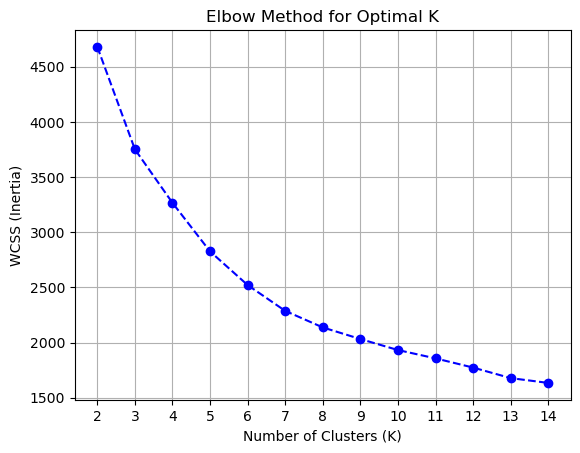

In [33]:
plt.plot(k,wcss,marker='o', linestyle='--', color='b')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.xticks(k)
plt.show()

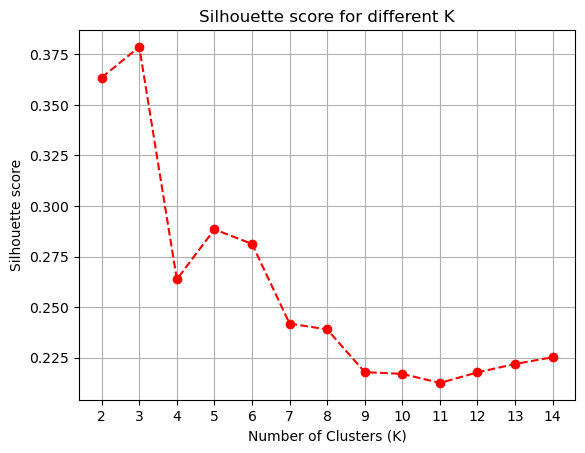

In [34]:
plt.plot(k,sil_score,marker='o', linestyle='--', color='r')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette score')
plt.title('Silhouette score for different K')
plt.grid(True)
plt.xticks(k)
plt.show()

In [35]:
# as per the elbow method and sillhoute score, the optimal number of clusters are 6

In [36]:
km_model = KMeans(n_clusters=6, random_state = 42).fit(telco_final)
km_pred = km_model.labels_
km_pred[:10]

array([0, 1, 3, 0, 0, 3, 0, 5, 3, 2])

In [37]:
print('silhouette_score :',silhouette_score(telco_final, km_pred))
print('inertia :',km_model.inertia_)

silhouette_score : 0.2812523121753702
inertia : 2520.7124234222815


In [38]:
km_model.cluster_centers_   # centroids of each cluster. here data in not 2d so each centroid  has 25 points

array([[-4.36228161e-01, -7.80938842e-01, -5.77472149e-01,
        -7.40235489e-01, -8.29283025e-01, -5.68447698e-01,
        -3.51669776e-01],
       [-4.24456778e-01,  1.47305263e-01,  1.10919342e+00,
         1.04493540e+00,  1.04417293e+00,  3.84151091e-02,
        -2.97015369e-01],
       [ 1.62541872e+00, -3.19285467e-01, -5.49783388e-01,
        -8.71997930e-01, -1.20141432e-01,  1.79618620e+00,
         2.99204687e-01],
       [-7.58129453e-02,  6.82426965e-01, -5.82445805e-01,
         2.09167498e-01,  4.34027400e-03, -2.27647760e-01,
        -6.11135827e-02],
       [ 1.33381155e+00,  7.18397528e-01,  9.83853859e-02,
         4.62484883e-01,  3.39833567e-01,  3.80873418e-01,
         4.41666131e+00],
       [ 6.21881893e-01,  1.49574645e+00,  2.00728561e+00,
         1.38087235e+00,  1.46320632e+00,  7.83611397e-01,
         3.97000786e-01]])

In [39]:
km_model.transform(telco_final)  # compute distance of each data point from each cluster centroid

array([[0.72459639, 3.61767339, 4.00802301, 2.43698965, 6.11062415,
        5.44336648],
       [3.21649488, 0.85074299, 4.35274156, 2.25800809, 5.42721051,
        2.51338142],
       [2.45431424, 2.99551078, 2.10496824, 1.55405793, 3.63213875,
        3.71506467],
       ...,
       [8.7800981 , 7.07672722, 7.60386161, 7.71321793, 3.92696868,
        5.76049074],
       [3.48503851, 3.24360498, 2.75649976, 1.96242142, 3.9353441 ,
        3.34628196],
       [1.67485551, 2.64869206, 2.35829163, 1.82789569, 5.19274571,
        4.20113755]])

In [40]:
from collections import Counter

In [41]:
cluster_counts = Counter(km_model.labels_)
total = sum(cluster_counts.values())

for cluster, count in cluster_counts.items():
    print(f"Cluster {cluster}: {count} ({count/total*100:.1f}%)")

Cluster 0: 397 (39.7%)
Cluster 1: 170 (17.0%)
Cluster 3: 203 (20.3%)
Cluster 5: 104 (10.4%)
Cluster 2: 96 (9.6%)
Cluster 4: 30 (3.0%)


##### Agglomerative clustering

In [42]:
from sklearn.cluster import AgglomerativeClustering

In [43]:
K = []
sill_score = []
 
for i in range(2, 12):
    agg = AgglomerativeClustering(n_clusters=i,linkage='ward')  
    labels = agg.fit_predict(telco_final)
    score = silhouette_score(telco_final, labels)
    K.append(i)
    sill_score.append(score)
 
    print(f'K: {i}, Silhouette Score: {score}')

K: 2, Silhouette Score: 0.33409740441687524
K: 3, Silhouette Score: 0.3679454115296911
K: 4, Silhouette Score: 0.2517656247062338
K: 5, Silhouette Score: 0.2641550635644778
K: 6, Silhouette Score: 0.25636634706096995
K: 7, Silhouette Score: 0.21298570125974792
K: 8, Silhouette Score: 0.21657943109463787
K: 9, Silhouette Score: 0.21044970694382698
K: 10, Silhouette Score: 0.2031449864562132
K: 11, Silhouette Score: 0.19738879104361484


In [44]:
agg_model = AgglomerativeClustering(n_clusters=4,linkage='ward').fit(telco_final)  
agg_pred = agg_model.labels_ 
agg_pred[:10]

array([2, 1, 3, 2, 2, 3, 2, 1, 3, 2], dtype=int64)

In [45]:
print('silhouette_score :',silhouette_score(telco_final, agg_pred))

silhouette_score : 0.2517656247062338


In [46]:
Counter(agg_pred)

Counter({2: 438, 1: 279, 3: 209, 0: 74})

##### DBSCAN

In [47]:
from sklearn.cluster import DBSCAN

In [48]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

eps = []
sil_score = []

for i in  np.round(np.arange(1.0, 3.0, 0.1),2):
    db = DBSCAN(eps=i, min_samples=5).fit(telco_final)
    labels = db.labels_
# Silhouette score can only be calculated if more than one cluster is formed because it tell how different two cluster are
    if len(set(labels)) > 2 or (len(set(labels)) == 2 and -1 not in labels):   
        score = silhouette_score(telco_final, labels)
    else:
        score = None     # when all points assigned -1 (noise points)

    eps.append(i)
    sil_score.append(score)      
    print(f"Eps: {i}, Clusters: {len(set(labels))-(-1 in labels)}, Noise: {list(labels).count(-1)}, Silhouette: {score}")

Eps: 1.0, Clusters: 2, Noise: 160, Silhouette: 0.12706288618854114
Eps: 1.1, Clusters: 2, Noise: 123, Silhouette: 0.20169577444785497
Eps: 1.2, Clusters: 2, Noise: 98, Silhouette: 0.19635613358505777
Eps: 1.3, Clusters: 2, Noise: 83, Silhouette: 0.22083045206499588
Eps: 1.4, Clusters: 1, Noise: 65, Silhouette: None
Eps: 1.5, Clusters: 1, Noise: 55, Silhouette: None
Eps: 1.6, Clusters: 1, Noise: 39, Silhouette: None
Eps: 1.7, Clusters: 1, Noise: 34, Silhouette: None
Eps: 1.8, Clusters: 1, Noise: 30, Silhouette: None
Eps: 1.9, Clusters: 1, Noise: 24, Silhouette: None
Eps: 2.0, Clusters: 1, Noise: 21, Silhouette: None
Eps: 2.1, Clusters: 1, Noise: 19, Silhouette: None
Eps: 2.2, Clusters: 2, Noise: 12, Silhouette: 0.5142232194735809
Eps: 2.3, Clusters: 2, Noise: 12, Silhouette: 0.5142232194735809
Eps: 2.4, Clusters: 1, Noise: 9, Silhouette: None
Eps: 2.5, Clusters: 1, Noise: 9, Silhouette: None
Eps: 2.6, Clusters: 1, Noise: 5, Silhouette: None
Eps: 2.7, Clusters: 1, Noise: 3, Silhouette: N

In [49]:
# i think The dataset has no strong density-based structure  as we only have just 1-2 clusters form with differet eps values

In [50]:
db_model = DBSCAN(eps = 2.2, min_samples= 5).fit(telco_final)  
db_pred = db_model.labels_ 
db_pred[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

In [51]:
print('silhouette_score :',silhouette_score(telco_final, db_pred))

silhouette_score : 0.5142232194735809


In [52]:
Counter(db_pred)

Counter({0: 983, -1: 12, 1: 5})


The objective of this analysis is to identify distinct behavioural customer segments using clustering techniques. Principal Component Analysis (PCA) was initially explored as a data reduction technique to address multicollinearity among the service variables. However, PCA retained only approximately 55–60% of the total variance within the first few principal components, indicating that a substantial amount of information would be lost while also reducing model interpretability.

To preserve the business meaning of the variables and maintain explainability, clustering was performed using the selected features instead of principal components. Multiple clustering algorithms, including K-Means, Agglomerative Clustering, and DBSCAN, were evaluated. Among these, K-Means produced the most balanced and interpretable customer segments, whereas the other algorithms resulted in highly imbalanced clusters with limited business usefulness.

The resulting clusters were profiled using demographic characteristics, service adoption, usage behaviour, spending patterns, and engineered customer metrics to reveal meaningful behavioural customer segments.

#### Profiling

In [53]:
df_profile = data_encd.copy()   

for k in [3, 4, 5, 6, 7]:      # here we can add the best perform k values
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(telco_final)         
    df_profile[f'KM{k}'] = km.labels_

profile_vars = ['tenure', 'age', 'income', 'employ', 'address', 'reside', 'ed', 'retire', 'gender', 'marital', 'region_1', 'region_2', 'region_3',
                'custcat_1', 'custcat_2', 'custcat_3', 'custcat_4', 'tollfree', 'equip', 'callcard', 'wireless', 'multline','voice', 'pager',
                'internet', 'callid', 'callwait', 'forward', 'confer', 'ebill','longmon', 'tollmon', 'equipmon', 'cardmon', 'wiremon', 'total_services',
                'total_mon_usage', 'avg_mon_usage','value_added_services', 'connectivity_services','usage_per_service', 'loyalty_score']

descriptions = {'tenure': 'Avg', 'age': 'Avg', 'income': 'Avg', 'employ': 'Avg', 'address': 'Avg', 'reside': 'Avg', 'ed': 'Avg',   # 7 continuous cols
                
                'retire': '% of retired', 'gender': '% of males', 'marital': '% married',       
                'region_1': '% of region', 'region_2': '% of region', 'region_5': '% of region',
                'custcat_1': '% of customers', 'custcat_2': '% of customers', 'custcat_5': '% of customers', 'custcat_4': '% of customers',   # 10 cat cols
                
                'tollfree': '% of customers', 'equip': '% of customers','callcard': '% of customers', 'wireless': '% of customers','multline': '% of customers',  # 5 connectivity_services
                
                'voice': '% of customers',  'pager': '% of customers', 'internet': '% of customers', 'callid': '% of customers', 'callwait': '% of customers',
                'forward': '% of customers', 'confer': '% of customers', 'ebill': '% of customers',  # 8 value added services
                
                'longmon': 'Avg', 'tollmon': 'Avg', 'equipmon': 'Avg','cardmon': 'Avg', 'wiremon': 'Avg',  # 5 usage cols
                
                'total_services': 'Avg', 'total_mon_usage': 'Avg', 'avg_mon_usage': 'Avg', 'value_added_services': 'Avg', 'connectivity_services': 'Avg',
                'usage_per_service': 'Avg', 'loyalty_score': 'Avg'}  # 7 engineered features


# Build profiling table 
KM_COLS = ['KM3', 'KM4', 'KM5', 'KM6', 'KM7']   # here we can adjust what k values we are taking 
rows = []

size_row = {'variable': 'Total', 'description': 'Percentage', 'overall': 1.0}  # form column structure for profiling 

for kcol in KM_COLS:    
    k = int(kcol.replace('KM', ''))       
    vc = df_profile[kcol].value_counts(normalize=True).sort_index()   
    for i in range(k):
        size_row[ f'{kcol}_{i+1}' ] = round(vc.get(i, 0), 2)  # insert key value pairs in size row dict to form the columns for profiling 
rows.append(size_row)

# Variable rows
for col in profile_vars:
    if col not in df_profile.columns:   # if column not in df_profile then ski
        print(f'skipped: {col}')
        continue
    row = {'variable': col, 'description': descriptions.get(col), 'overall': round(df_profile[col].mean(), 2)}  # add corresponding value on each column
    for kcol in KM_COLS:
        k = int(kcol.replace('KM', ''))
        for i in range(k):
            row[f'{kcol}_{i+1}'] = round(df_profile.loc[df_profile[kcol] == i, col].mean(), 2)  # add  mean of each segment columns 
    rows.append(row)

profiling = pd.DataFrame(rows)

# Save 
profiling.to_excel('Profiling.xlsx', index=False)
print('Profilin shape:', profiling.shape)

Profilin shape: (43, 28)


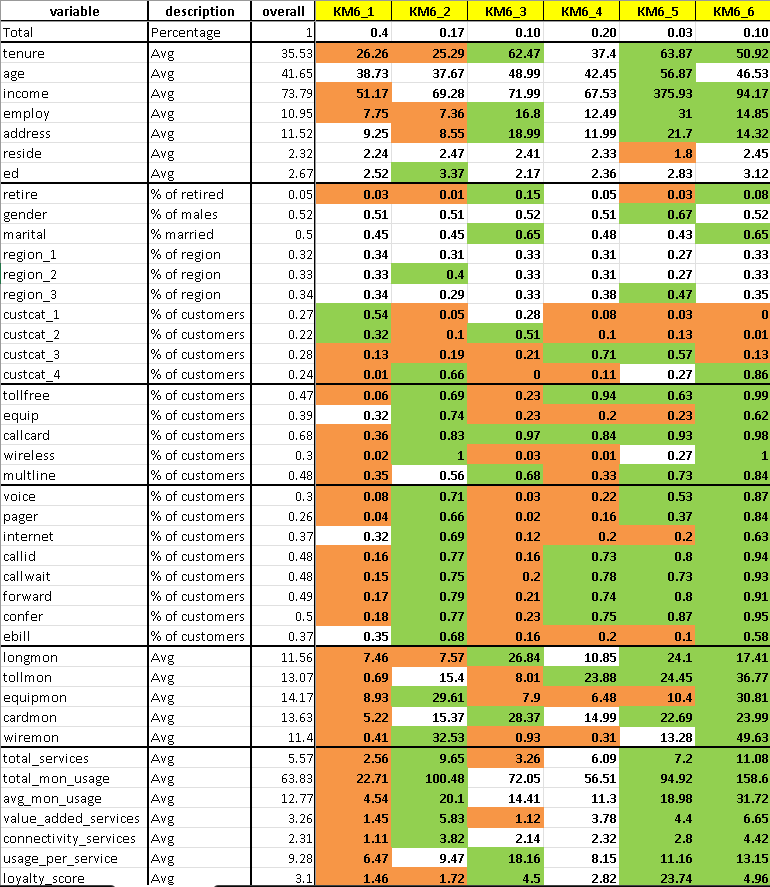

In [54]:
# visulaize Profiling 
from IPython.display import Image, display
display(Image(filename='profiling.png', width=1000 ))

In [55]:
data_encd['KM6'] = km_pred

segment_names = {0: "Basic Users",1: "Wireless & Tech Enthusiasts",2: "Long-Tenure Traditional Customers",3: "Value-Added Service Adopters",
                 4: "VIP Customers",5: "Heavy Users"}

data_encd["KM6"] = data_encd["KM6"].map(segment_names)
df_profile["KM6"] = df_profile["KM6"].map(segment_names)

# Customer Segment Characteristics 

### KM6_1 – Basic Customers (40%)

- Largest customer segment.
- Lowest income, shortest tenure, and lowest loyalty.
- Uses only a few basic telecom services.
- Lowest monthly usage and spending.
- Limited adoption of connectivity and value-added services.

**Behaviour:** Entry-level customers with minimal engagement.

---

### KM6_2 – Connected Digital Customers (17%)

- Moderate income with relatively short tenure.
- High adoption of Wireless, Internet, Equipment, Voice Mail and Pager.
- Uses nearly ten telecom services.
- High monthly usage and strong digital engagement.

**Behaviour:** Technology-oriented customers willing to adopt multiple digital services.

---

### KM6_3 – Traditional Long-Term Customers (10%)

- Longest-tenured customers after KM6_5.
- Older customer base with higher retirement rate.
- Heavy users of traditional calling services.
- Very low adoption of Wireless and Internet services.

**Behaviour:** Loyal but traditional customers who have been slow to adopt modern telecom services.

---

### KM6_4 – Communication Service Users (20%)

- Strong adoption of Toll-Free, Caller ID, Call Waiting, Call Forwarding and Conference Calling.
- Moderate income and service usage.
- Lower adoption of Wireless and Internet services.

**Behaviour:** Customers focused primarily on communication-related services.

---

### KM6_5 – Premium Loyal Customers (3%)

- Highest income and longest tenure.
- Exceptional loyalty score.
- Long employment history.
- High service usage across premium offerings.

**Behaviour:** Small but extremely valuable customer segment with strong purchasing power and long-term loyalty.

---

### KM6_6 – Power Users (10%)

- Highest number of subscribed services.
- Highest monthly usage and spending.
- Extensive adoption of both connectivity and value-added services.
- High income with strong customer loyalty.

**Behaviour:** Heavy telecom users generating the highest revenue for the business.

In [56]:
data_encd.columns

Index(['tenure', 'age', 'marital', 'address', 'income', 'ed', 'employ',
       'retire', 'gender', 'reside', 'tollfree', 'equip', 'callcard',
       'wireless', 'multline', 'voice', 'pager', 'internet', 'callid',
       'callwait', 'forward', 'confer', 'longmon', 'tollmon', 'equipmon',
       'cardmon', 'wiremon', 'ebill', 'region_1', 'region_2', 'region_3',
       'custcat_1', 'custcat_2', 'custcat_3', 'custcat_4', 'total_services',
       'total_mon_usage', 'avg_mon_usage', 'value_added_services',
       'connectivity_services', 'usage_per_service', 'loyalty_score', 'KM6'],
      dtype='object')

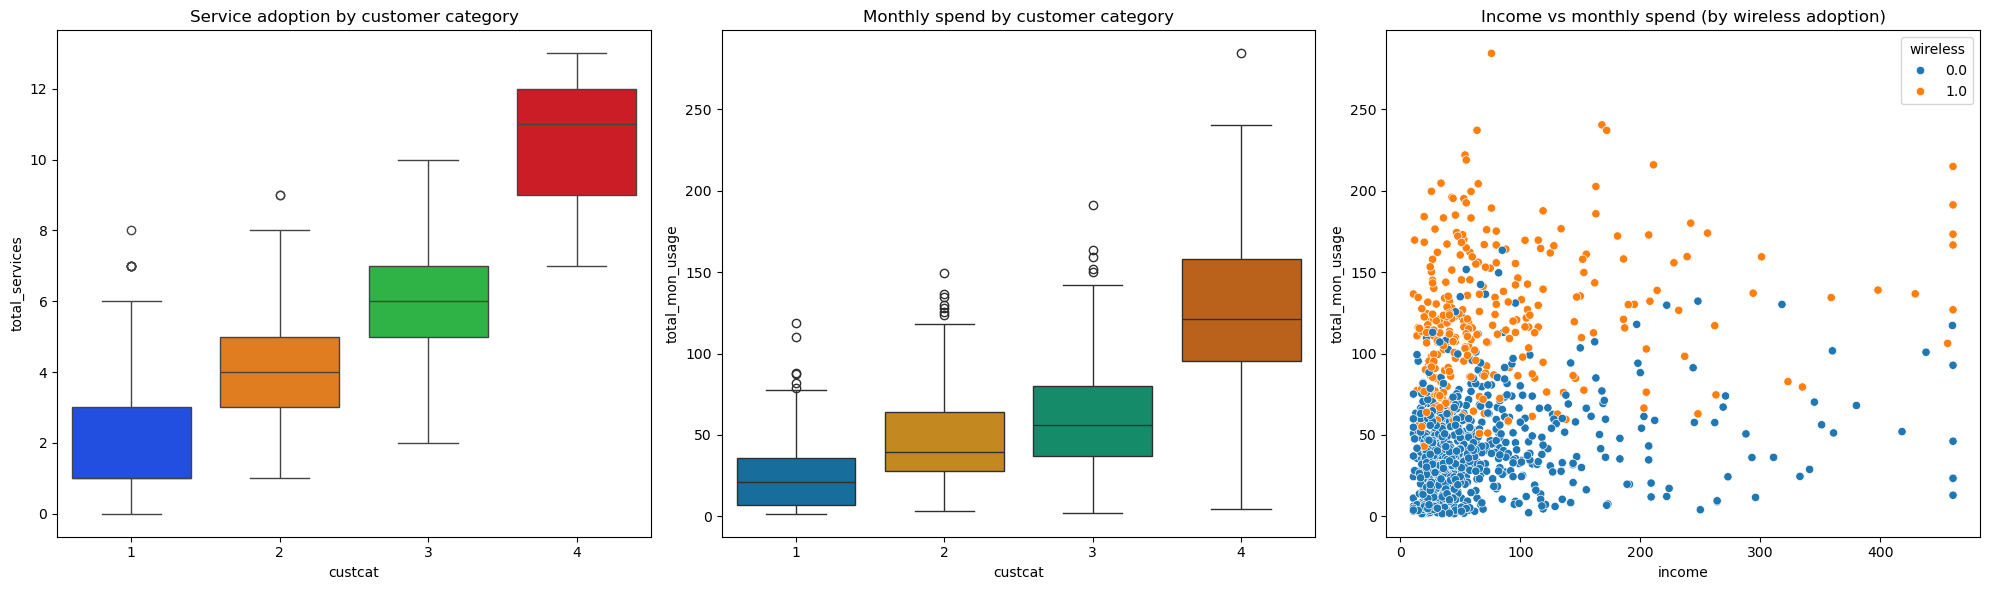

In [57]:
data_plot = data_encd.copy()
data_plot['custcat'] = ( data_plot[['custcat_1','custcat_2','custcat_3','custcat_4']].idxmax(axis=1).str[-1].astype(int))
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# service adoption by customer category
sns.boxplot(x='custcat',y='total_services',data=data_plot, palette= 'bright',ax=axes[0])
axes[0].set_title('Service adoption by customer category')

# monthly spend by customer category
sns.boxplot(x='custcat',y='total_mon_usage',data=data_plot,palette= 'colorblind', ax=axes[1])
axes[1].set_title('Monthly spend by customer category')

# income vs total spend, colored by wireless adoption
sns.scatterplot(x='income',y='total_mon_usage',hue='wireless',data=data_plot, ax=axes[2])
axes[2].set_title('Income vs monthly spend (by wireless adoption)')

plt.tight_layout()
plt.show()

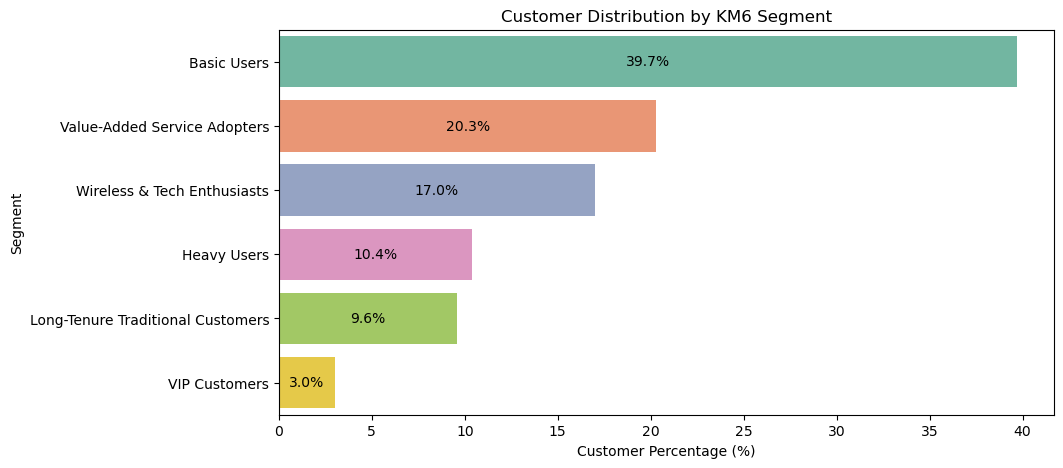

In [248]:
#  segment sizes
segment_pct = data_encd['KM6'].value_counts(normalize=True).mul(100).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
ax = sns.barplot(x = segment_pct.values, y = segment_pct.index.astype(str),palette='Set2')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%',label_type='center')
plt.xlabel('Customer Percentage (%)')
plt.ylabel('Segment')
plt.title('Customer Distribution by KM6 Segment')
plt.show()

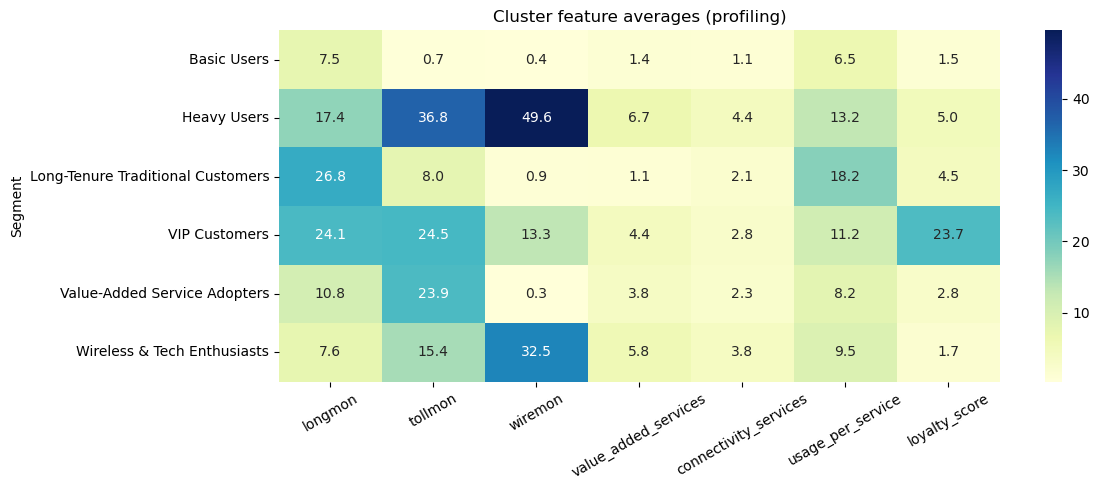

In [249]:
# heatmap of mean cluster features per segment 
profile = data_encd.groupby('KM6')[cluster_features].mean()
plt.figure(figsize=(12, 5))
sns.heatmap(profile, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Cluster feature averages (profiling)')
plt.ylabel('Segment')
plt.xticks(rotation = 30)
plt.tight_layout()
plt.show()

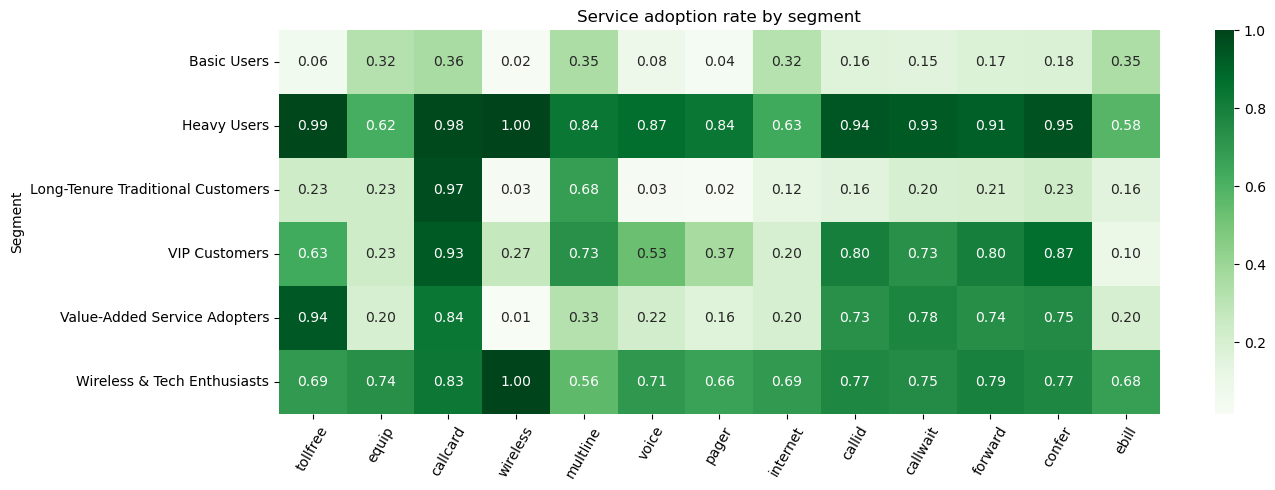

In [250]:
# service adoption rate by segment — drives upsell strategy
plt.figure(figsize=(14, 5))
sns.heatmap(data_encd.groupby('KM6')[service_cols].mean(),
            annot=True, fmt='.2f', cmap='Greens')
plt.title('Service adoption rate by segment')
plt.ylabel('Segment')
plt.xticks(rotation = 60)
plt.tight_layout()
plt.show()

In [251]:
# pip install mlxtend  
from mlxtend.frequent_patterns import apriori, association_rules

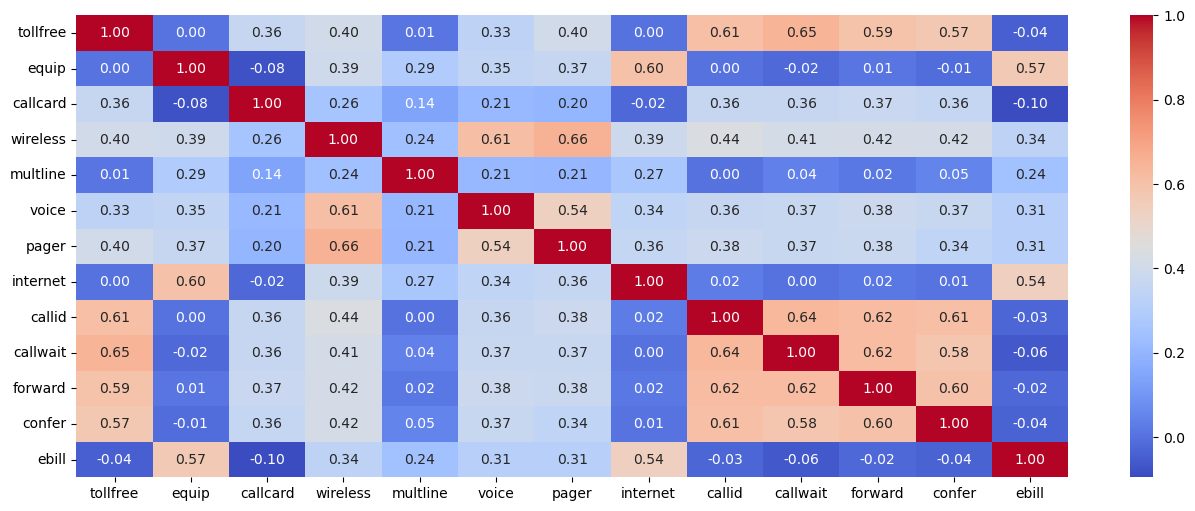

In [252]:
plt.figure(figsize=(16,6))
sns.heatmap(data_encd[service_cols].corr(), annot = True, fmt = '.2f', cmap = 'coolwarm')
plt.show()

In [253]:
# Associations and affinities between services using mlextent apriori, association rule minning 

basket = data_encd[service_cols].astype(bool)

freq_items = apriori(basket, min_support=0.10, max_len=5, use_colnames=True)
rules = association_rules(freq_items, metric='lift', min_threshold=1.7)      # generate rules

rules = rules[(rules['confidence'] >= 0.70) & (rules['support'] >= 0.10)].copy()  #Keep only meaningful rule
rules = rules[(rules['antecedents'].apply(len) == 2) & (rules['consequents'].apply(len) == 1)]  # (keep 2 antecedent services predict consequent 1 service)

rules['Antecedent'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))  # for better readibility
rules['Consequent'] = rules['consequents'].apply(lambda x: ', '.join(sorted(list(x))))
 
rules = rules[['Antecedent','Consequent','support','confidence','lift']]  # subsetting 

rules = rules.round({'support':5,'confidence':5,'lift':2})       

# Keep the top rules for each recommended service
#top_rules = (rules.sort_values(['Consequent', 'lift', 'confidence', 'support'],ascending=[True, False, False, False]).groupby('Consequent').head(5).reset_index(drop=True)) 
#top_rules = rules.sort_values(['lift','confidence','support'], ascending=False, ignore_index = True)

rules = rules.sort_values(['lift','confidence','support'], ascending=False, ignore_index = True)
#rules.columns = ['Current Services','Likely Next Service','Support','Confidence','Lift']
rules.to_excel('Telecom Associations Rules.xlsx',index = False)

display('All Association Rules:', rules)

'All Association Rules:'

,Antecedent,Consequent,support,confidence,lift
0,"pager, voice",wireless,0.171,0.90957,3.07
1,"voice, wireless",pager,0.171,0.78082,2.99
2,"internet, wireless",pager,0.151,0.77835,2.98
3,"internet, pager",wireless,0.151,0.87791,2.97
4,"callid, pager",wireless,0.183,0.87560,2.96
...,...,...,...,...,...
306,"callcard, confer",tollfree,0.345,0.81176,1.71
307,"callid, multline",confer,0.196,0.85590,1.70
308,"callcard, forward",confer,0.360,0.85511,1.70
309,"voice, wireless",callwait,0.181,0.82648,1.70


In [254]:
rules['Consequent'].value_counts()

Consequent
wireless    36
voice       36
callid      31
callwait    30
forward     29
pager       28
equip       27
tollfree    27
internet    25
confer      25
ebill       17
Name: count, dtype: int64

In [255]:
# Prepare telecom business summary

telecom_summary = (rules.sort_values("lift", ascending=False).groupby("Consequent").agg({"Antecedent": lambda x: " | ".join(x.head(5)),"lift": "max",
                                                                                          "confidence": "max"})).reset_index()
telecom_summary.columns = ['Recommended Service','Strong Affinities','Best Lift','Confidence']
telecom_summary = telecom_summary.sort_values(by = 'Best Lift', ascending = False, ignore_index = True)

# save the Association rules summary
telecom_summary.to_excel('Telecom Associations Rules Summary.xlsx',index = False)
telecom_summary

# Note: The association rules below are ordered from the strongest to the weakest affinity 

,Recommended Service,Strong Affinities,Best Lift,Confidence
0,wireless,"pager, voice | internet, pager | callid, pager...",3.07,0.90957
1,pager,"voice, wireless | internet, wireless | interne...",2.99,0.78082
2,voice,"pager, wireless | equip, wireless | ebill, wir...",2.69,0.81818
3,equip,"ebill, pager | internet, pager | ebill, wirele...",2.26,0.87117
4,internet,"equip, pager | ebill, wireless | equip, wirele...",2.26,0.83240
5,ebill,"internet, voice | equip, pager | equip, voice ...",2.14,0.79330
6,callid,"confer, pager | confer, wireless | callwait, w...",1.94,0.93204
7,tollfree,"callwait, pager | forward, pager | confer, pag...",1.92,0.90865
8,callwait,"tollfree, voice | confer, pager | tollfree, wi...",1.89,0.91855
9,forward,"confer, pager | tollfree, wireless | tollfree,...",1.87,0.92233


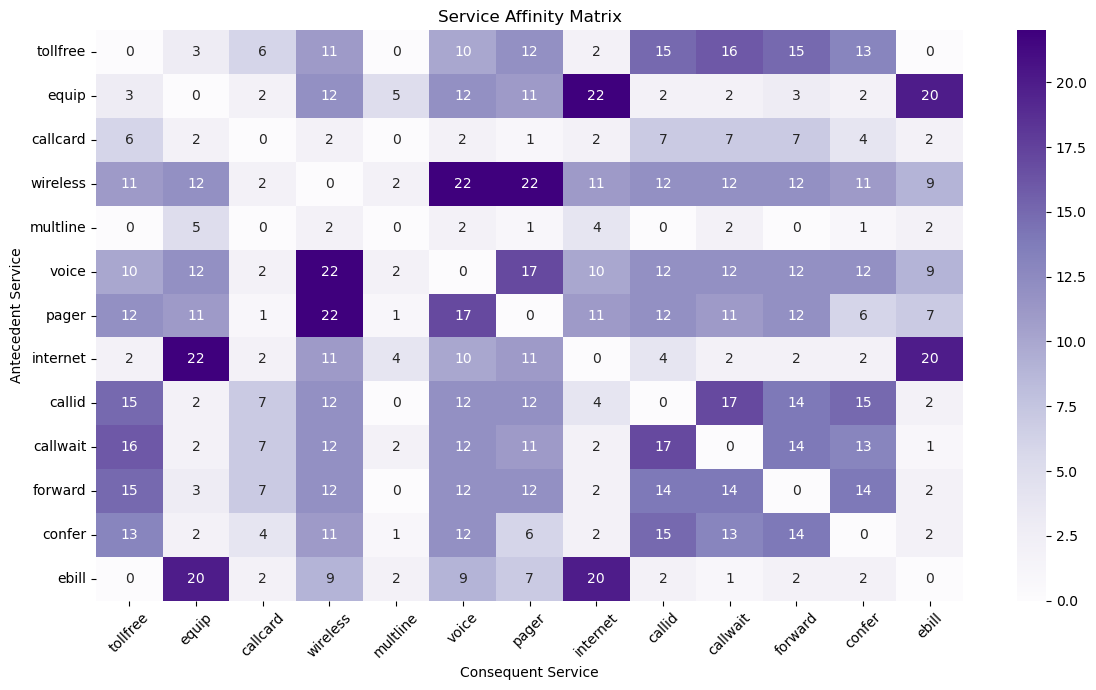

In [256]:
# Service Affinity matrix to summarizes the relationships between services.

services = service_cols
matrix = pd.DataFrame(0,index=services,columns=services) # Create a null matrix.

for i, row in rules.iterrows():  # to go through each row of data, i = index as because .iterrow() df function returns index and df each row
    antecedents = row['Antecedent'].split(', ')
    consequent = row['Consequent']
    for service in antecedents:
        matrix.loc[service, consequent] += 1     
        matrix.loc[consequent, service] += 1     # to make both directions similar 

plt.figure(figsize=(12,7))
sns.heatmap(matrix,annot=True,cmap='Purples', fmt='d')
plt.title('Service Affinity Matrix')
plt.xlabel('Consequent Service')
plt.ylabel('Antecedent Service')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Note: Higher values indicate stronger co-occurrence (affinity) between services,

## Business Insights: Service Relationships and Affinities

### Objective
The objective of this analysis is to identify relationships and affinities between telecom services to understand which services are frequently adopted together. These insights help the business design bundled offerings, improve cross-selling strategies, and increase customer lifetime value.

---

## Key Findings

### 1. Wireless acts as the central service in the telecom portfolio.
- Wireless shows strong relationships with Voice Mail (0.61), Pager (0.66), Internet (0.39), and several calling services.
- Association Rule Mining also identifies Wireless as the strongest recommended service (Lift = 3.07, Confidence = 90.96%).

**Business Insight:**
Wireless should be treated as the anchor product for bundled plans and targeted cross-selling campaigns.

---

### 2. Calling features are frequently adopted together.
Strong positive relationships exist among:
- Caller ID
- Call Waiting
- Call Forwarding
- Conference Calling
- Toll-Free

Correlation values range between **0.57 and 0.65**, while association rules show confidence levels above **90%**.

**Business Insight:**
Instead of promoting these services individually, they should be offered as integrated communication bundles to increase adoption.

---

### 3. Voice Mail and Pager form a strong service combination.
Both services exhibit:
- High correlation
- High association strength (Lift = 2.99 for Pager and 2.69 for Voice)

**Business Insight:**
Customers subscribing to one of these services are highly likely to adopt the other, making them excellent candidates for bundled promotions.

---

### 4. Internet and Equipment services show strong affinity.
- Correlation between Equipment and Internet = **0.60**
- Association rules also identify strong relationships between these services.

**Business Insight:**
Customers purchasing Internet services should be targeted with Equipment rental offers and related digital services.

---

### 5. Electronic Billing is closely associated with digital services.
Electronic Billing demonstrates strong relationships with:
- Internet
- Equipment
- Wireless

**Business Insight:**
Promoting e-Billing during digital service activation can improve digital adoption while reducing operational costs.

---

### 6. Multiline service shows relatively weak associations.
Compared to other telecom services, Multiline has weaker relationships with most service categories.

**Business Insight:**
Multiline appears to satisfy specific customer requirements and may require targeted marketing rather than broad cross-selling campaigns.

---

## Overall Business Conclusion

The analysis indicates that telecom services are generally adopted in groups rather than independently. Three major service ecosystems emerge:

- **Wireless Ecosystem:** Wireless, Voice Mail, Pager, and Internet
- **Communication Feature Ecosystem:** Toll-Free, Caller ID, Call Waiting, Call Forwarding, and Conference Calling
- **Digital Ecosystem:** Internet, Equipment Rental, and Electronic Billing

These findings suggest that bundled offerings and personalized cross-selling strategies are likely to be more effective than promoting individual services. Leveraging these service affinities can improve customer adoption, increase average revenue per customer (ARPU), and strengthen customer retention.

# Strategic Insights

The customer segmentation analysis reveals six distinct behavioural groups with significantly different demographic profiles, service adoption patterns, and revenue potential.

### Revenue Growth

Power Users (KM6_6) represent the strongest opportunity for revenue growth due to their extensive service adoption and highest monthly usage. Premium service bundles and new product launches should primarily target this segment.

### Customer Retention

Premium Loyal Customers (KM6_5) contribute disproportionately high customer value despite representing only a small proportion of the customer base. Retaining these customers should remain a strategic priority.

### Cross-selling Opportunities

Connected Digital Customers (KM6_2) and Communication Service Users (KM6_4) exhibit strong potential for additional service adoption through targeted cross-selling and bundled offerings.

### Digital Migration

Traditional Long-Term Customers (KM6_3) continue to rely heavily on conventional telecom services. Gradual migration toward digital and connectivity services can increase their long-term value while preserving customer loyalty.

### Customer Development

Basic Customers (KM6_1) represent the largest segment but currently generate the lowest value. Affordable bundled plans and introductory offers can encourage gradual service adoption and improve customer lifetime value.

# Implementation Strategy

| Customer Segment | Business Objective | Recommended Strategy |
|-----------------|-------------------|----------------------|
| **KM6_1 – Basic Customers** | Increase service adoption | Promote affordable entry-level bundles, introductory offers, and personalized cross-selling campaigns. |
| **KM6_2 – Connected Digital Customers** | Increase Average Revenue Per User (ARPU) | Launch premium digital bundles, device upgrade offers, and new digital services. |
| **KM6_3 – Traditional Long-Term Customers** | Digital transformation | Encourage migration to Internet and Wireless services through education, incentives, and bundled migration plans. |
| **KM6_4 – Communication Service Users** | Upsell connectivity services | Bundle communication features with Internet and Wireless packages to increase service adoption. |
| **KM6_5 – Premium Loyal Customers** | Customer retention | Provide VIP support, exclusive rewards, personalized offers, and proactive relationship management. |
| **KM6_6 – Power Users** | Revenue maximization | Launch premium bundles, early access to new services, loyalty rewards, and proactive retention programs. |